In [336]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
import ast

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)
""
print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [337]:
df = pd.read_csv('../Myun_EDA/preprocessed_final.csv')
sorted_df = df.sort_values(by=['customer_id','time'])

In [338]:
df['offer_id'].value_counts()

offer_id
fafdcd668e3743c1bb461111dcafc2a4    20241
2298d6c36e964ae4a3e7e9706d1fb8c2    20139
f19421c1d4aa40978ebb69ca19b0e20d    19131
4d5c57ea9a6940dd891ad53e9dbe8da0    18222
ae264e3637204a6fb9bb56bc8210ddfd    18062
9b98b8c7a33c4b65b9aebfe6a799e6d9    16202
2906b810c7d4411798c6938adc9daaa5    15767
5a8bc65990b245e5a138643cd4eb9837    14305
0b1e1539f2cc45b7b9fa7c272da2e1d7    13751
3f207df678b143eea3cee63160fa8bed    11761
Name: count, dtype: int64

In [339]:
df[df['event']=='offer completed']['offer_id'].value_counts() # offer completed 인 offer는 8개 (10개 중)

offer_id
fafdcd668e3743c1bb461111dcafc2a4    5317
2298d6c36e964ae4a3e7e9706d1fb8c2    5156
9b98b8c7a33c4b65b9aebfe6a799e6d9    4354
f19421c1d4aa40978ebb69ca19b0e20d    4296
2906b810c7d4411798c6938adc9daaa5    4017
ae264e3637204a6fb9bb56bc8210ddfd    3688
0b1e1539f2cc45b7b9fa7c272da2e1d7    3420
4d5c57ea9a6940dd891ad53e9dbe8da0    3331
Name: count, dtype: int64

In [340]:
df

,customer_id,event,time,amount,offer_id,day,reward,difficulty,duration,offer_type,ch_web,ch_email,ch_mobile,ch_social,channel_count,reward_ratio,offer_strength,gender,age,became_member_on,income,is_profile_missing,age_group,age_gender,income_group
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,0,5.0,5.0,7.0,bogo,1.0,1.0,1.0,0.0,3.0,1.00,0.0,F,75.0,2017-05-09,100000.0,0,60대 이상,60+ 여성,10만 이상
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,0,5.0,20.0,10.0,discount,1.0,1.0,0.0,0.0,2.0,0.25,-15.0,Unknown,NaN,2017-08-04,0.0,1,누락,미기입,누락
2,e2127556f4f64592b11af22de27a7932,offer received,0,NaN,2906b810c7d4411798c6938adc9daaa5,0,2.0,10.0,7.0,discount,1.0,1.0,1.0,0.0,3.0,0.20,-8.0,M,68.0,2018-04-26,70000.0,0,60대 이상,60대 남성,5-7.5만
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,NaN,fafdcd668e3743c1bb461111dcafc2a4,0,2.0,10.0,10.0,discount,1.0,1.0,1.0,1.0,4.0,0.20,-8.0,Unknown,NaN,2017-09-25,0.0,1,누락,미기입,누락
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,0,10.0,10.0,5.0,bogo,1.0,1.0,1.0,1.0,4.0,1.00,0.0,Unknown,NaN,2017-10-02,0.0,1,누락,미기입,누락
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,714,1.59,NaN,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M,66.0,2018-01-01,47000.0,0,60대 이상,60대 남성,5만 미만
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,714,9.53,NaN,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M,52.0,2018-04-08,62000.0,0,50대,50대 남성,5-7.5만
306531,a00058cf10334a308c68e7631c529907,transaction,714,3.61,NaN,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F,63.0,2013-09-22,52000.0,0,60대 이상,60대 여성,5-7.5만
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,714,3.53,NaN,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M,57.0,2016-07-09,40000.0,0,50대,50대 남성,5만 미만


In [341]:
# ==========================
# viewed 이후 completed 이벤트 플래그
# 이벤트를 인지하고 결제가 이루어졌는지를 확인하는 용도
# is_aware == True : offer가 구매에 영향을 주었을 가능성 높음 (마케팅 효과 있음)
# is_aware == False : 오퍼를 보기 전에 이미 구매했거나 오퍼 존재 자체를 모른체 구매 (마케팅 효과 없음)
# ==========================
df_view = df[df['event'] == 'offer viewed'][['customer_id', 'offer_id', 'time']] # view 이벤트 테이블
df_complete = df[df['event'] == 'offer completed'][['customer_id', 'offer_id', 'time']] # complete 이벤트 테이블
merged_df = pd.merge(df_complete, df_view, on=['customer_id', 'offer_id'], how='left', suffixes=('_comp', '_view'))
merged_df['is_aware'] = merged_df['time_view'] < merged_df['time_comp'] 

# is_aware가 True인 것을 가장 위로 올리고 (True는 보통 1, False는 0이므로 내림차순 정렬)
# 그중에서도 완료 직전의 조회를 찾기 위해 time_view를 내림차순 정렬
merged_df = merged_df.sort_values(
    by=['customer_id', 'time_comp', 'is_aware', 'time_view'], 
    ascending=[True, True, False, False] 
).drop_duplicates(
    subset=['customer_id', 'offer_id', 'time_comp'], 
    keep='first'
)

# 병합 전과 후의 행 수 확인
print(f"병합 전 : {len(df_complete)}, 병합 후 : {len(merged_df)}")
dup_comp = df_complete.duplicated(subset=['customer_id', 'offer_id', 'time']).sum()
print(f"df_complete의 중복 행 수 : {dup_comp}")
display(merged_df)

병합 전 : 33579, 병합 후 : 33182
df_complete의 중복 행 수 : 397


,customer_id,offer_id,time_comp,time_view,is_aware
19009,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,414,456.0,False
29211,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,528,540.0,False
33136,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,NaN,False
11281,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,252,186.0,True
33157,0011e0d4e6b944f998e987f904e8c1e5,9b98b8c7a33c4b65b9aebfe6a799e6d9,576,516.0,True
...,...,...,...,...,...
8406,ffff82501cea40309d5fdd7edcca4a07,0b1e1539f2cc45b7b9fa7c272da2e1d7,198,174.0,True
16771,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,384,354.0,True
18926,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,414,354.0,True
26299,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,534.0,False


merged_df는 customer_id당 같은 offer_id별로 event=='offer complete'인 한 건만 포함

In [342]:
merged_df['offer_id'].value_counts()

offer_id
fafdcd668e3743c1bb461111dcafc2a4    5265
2298d6c36e964ae4a3e7e9706d1fb8c2    5112
9b98b8c7a33c4b65b9aebfe6a799e6d9    4303
f19421c1d4aa40978ebb69ca19b0e20d    4262
2906b810c7d4411798c6938adc9daaa5    3964
ae264e3637204a6fb9bb56bc8210ddfd    3635
0b1e1539f2cc45b7b9fa7c272da2e1d7    3340
4d5c57ea9a6940dd891ad53e9dbe8da0    3301
Name: count, dtype: int64

In [343]:
# is_aware가 True인 비율 확인
# '우연히' 완료된 건수와 '이벤트를 인지하여' 완료한 건수의 비중 비교
awareness_report = merged_df.groupby('offer_id')['is_aware'].value_counts(normalize=True)
print(awareness_report)

offer_id                          is_aware
0b1e1539f2cc45b7b9fa7c272da2e1d7  False       0.588922
                                  True        0.411078
2298d6c36e964ae4a3e7e9706d1fb8c2  True        0.804773
                                  False       0.195227
2906b810c7d4411798c6938adc9daaa5  True        0.533300
                                  False       0.466700
4d5c57ea9a6940dd891ad53e9dbe8da0  True        0.768858
                                  False       0.231142
9b98b8c7a33c4b65b9aebfe6a799e6d9  False       0.516849
                                  True        0.483151
ae264e3637204a6fb9bb56bc8210ddfd  True        0.677304
                                  False       0.322696
f19421c1d4aa40978ebb69ca19b0e20d  True        0.754810
                                  False       0.245190
fafdcd668e3743c1bb461111dcafc2a4  True        0.838746
                                  False       0.161254
Name: proportion, dtype: float64


### 이벤트 마케팅 효과 좋았던 오퍼 
- fafdcd668e3743c1bb461111dcafc2a4 (0.838746)
- 2298d6c36e964ae4a3e7e9706d1fb8c2 (0.804773)
- 4d5c57ea9a6940dd891ad53e9dbe8da0 (0.768858)
- f19421c1d4aa40978ebb69ca19b0e20d (0.754810)

### 이벤트 마케팅 효과 별로였던 오퍼 (is_aware==False 비중이 더 높은 오퍼)
- 0b1e1539f2cc45b7b9fa7c272da2e1d7 (0.588922)
- 9b98b8c7a33c4b65b9aebfe6a799e6d9 (0.516849)

In [344]:
merged_df2 = merged_df.drop(columns=['time_comp','time_view']).copy()

In [345]:
# 전체 데이터프레임과 is_aware 포함한 데이터프레임 병합
full_df = pd.merge(df, merged_df2, on=['customer_id', 'offer_id'], how='left')
full_df

,customer_id,event,time,amount,offer_id,day,reward,difficulty,duration,offer_type,ch_web,ch_email,ch_mobile,ch_social,channel_count,reward_ratio,offer_strength,gender,age,became_member_on,income,is_profile_missing,age_group,age_gender,income_group,is_aware
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,0,5.0,5.0,7.0,bogo,1.0,1.0,1.0,0.0,3.0,1.00,0.0,F,75.0,2017-05-09,100000.0,0,60대 이상,60+ 여성,10만 이상,True
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,0,5.0,20.0,10.0,discount,1.0,1.0,0.0,0.0,2.0,0.25,-15.0,Unknown,NaN,2017-08-04,0.0,1,누락,미기입,누락,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,0,NaN,2906b810c7d4411798c6938adc9daaa5,0,2.0,10.0,7.0,discount,1.0,1.0,1.0,0.0,3.0,0.20,-8.0,M,68.0,2018-04-26,70000.0,0,60대 이상,60대 남성,5-7.5만,NaN
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,NaN,fafdcd668e3743c1bb461111dcafc2a4,0,2.0,10.0,10.0,discount,1.0,1.0,1.0,1.0,4.0,0.20,-8.0,Unknown,NaN,2017-09-25,0.0,1,누락,미기입,누락,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,0,10.0,10.0,5.0,bogo,1.0,1.0,1.0,1.0,4.0,1.00,0.0,Unknown,NaN,2017-10-02,0.0,1,누락,미기입,누락,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332713,b3a1272bc9904337b331bf348c3e8c17,transaction,714,1.59,NaN,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M,66.0,2018-01-01,47000.0,0,60대 이상,60대 남성,5만 미만,NaN
332714,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,714,9.53,NaN,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M,52.0,2018-04-08,62000.0,0,50대,50대 남성,5-7.5만,NaN
332715,a00058cf10334a308c68e7631c529907,transaction,714,3.61,NaN,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F,63.0,2013-09-22,52000.0,0,60대 이상,60대 여성,5-7.5만,NaN
332716,76ddbd6576844afe811f1a3c0fbb5bec,transaction,714,3.53,NaN,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M,57.0,2016-07-09,40000.0,0,50대,50대 남성,5만 미만,NaN


In [346]:
# ================
# 인지율
# (오퍼를 완료한 고객 중에 오퍼를 인지하고 완료한 비율)
# ================

# 1. 오퍼별 특성(채널, 오퍼 타입, 기간, 리워드 등)만 모은 마스터 테이블 생성
# reward_ratio = reward / difficulty 
# offer_strength = reward - difficulty 
offer_info = df[['offer_id', 'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'offer_type', 'duration', 'reward', 'difficulty', 'reward_ratio', 'offer_strength']].drop_duplicates().copy()

# 2. 오퍼별 전체 발송(received) 횟수 계산
total_received = df[df['event'] == 'offer received'].groupby('offer_id').size().rename('received_count')

# 3. merged_df에서 오퍼별 is_aware 통계 계산 
# (merged_df는 customer_id당 같은 offer_id별로 event=='offer complete'인 한 건만 포함하므로 중복 위험 없음)
# True는 1, False는 0이므로 mean()이 '인지율'
aware_stats = merged_df.groupby('offer_id')['is_aware'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'total_completed', 'sum': 'aware_completed', 'mean': 'aware_rate'}
)

# 4. 데이터 합치기
analysis_df = offer_info.merge(total_received, on='offer_id').merge(aware_stats, on='offer_id', how='left')
# analysis_df.to_csv('../Myun_EDA/analysis_offer_df.csv')

# 5. 채널별 인지율 확인을 위한 정렬
# is_aware가 True인 비율(aware_rate)이 높은 순서대로 정렬
display(analysis_df.sort_values('aware_rate', ascending=False))

,offer_id,ch_web,ch_email,ch_mobile,ch_social,channel_count,offer_type,duration,reward,difficulty,reward_ratio,offer_strength,received_count,total_completed,aware_completed,aware_rate
3,fafdcd668e3743c1bb461111dcafc2a4,1.0,1.0,1.0,1.0,4.0,discount,10.0,2.0,10.0,0.200000,-8.0,7597,5265.0,4416.0,0.838746
6,2298d6c36e964ae4a3e7e9706d1fb8c2,1.0,1.0,1.0,1.0,4.0,discount,7.0,3.0,7.0,0.428571,-4.0,7646,5112.0,4114.0,0.804773
4,4d5c57ea9a6940dd891ad53e9dbe8da0,1.0,1.0,1.0,1.0,4.0,bogo,5.0,10.0,10.0,1.000000,0.0,7593,3301.0,2538.0,0.768858
5,f19421c1d4aa40978ebb69ca19b0e20d,1.0,1.0,1.0,1.0,4.0,bogo,5.0,5.0,5.0,1.000000,0.0,7571,4262.0,3217.0,0.754810
8,ae264e3637204a6fb9bb56bc8210ddfd,0.0,1.0,1.0,1.0,3.0,bogo,7.0,10.0,10.0,1.000000,0.0,7658,3635.0,2462.0,0.677304
2,2906b810c7d4411798c6938adc9daaa5,1.0,1.0,1.0,0.0,3.0,discount,7.0,2.0,10.0,0.200000,-8.0,7632,3964.0,2114.0,0.533300
0,9b98b8c7a33c4b65b9aebfe6a799e6d9,1.0,1.0,1.0,0.0,3.0,bogo,7.0,5.0,5.0,1.000000,0.0,7677,4303.0,2079.0,0.483151
1,0b1e1539f2cc45b7b9fa7c272da2e1d7,1.0,1.0,0.0,0.0,2.0,discount,10.0,5.0,20.0,0.250000,-15.0,7668,3340.0,1373.0,0.411078
7,3f207df678b143eea3cee63160fa8bed,1.0,1.0,1.0,0.0,3.0,informational,4.0,0.0,0.0,0.000000,0.0,7617,NaN,NaN,NaN
9,5a8bc65990b245e5a138643cd4eb9837,0.0,1.0,1.0,1.0,3.0,informational,3.0,0.0,0.0,0.000000,0.0,7618,NaN,NaN,NaN


In [347]:
# ================
# 전환율
# (오퍼를 본 고객 중에 오퍼를 인지하고 완료를 한 비율)
# ================

# 1. 분모: 오퍼별 유니크 시청 고객 수 (Viewed)
# series 객체이기 때문에 인덱스가 offer_id로 설정
view_counts = df[df['event'] == 'offer viewed'].groupby('offer_id')['customer_id'].nunique().rename('view_unique_count')

# 2. 분자: 오퍼를 인지하고 완료한 유니크 고객 수 (Aware & Completed)
# '조회한 사람 중' 완료한 사람을 찾아야 하므로 merged_df 활용
complete_aware_counts = merged_df[merged_df['is_aware'] == True].groupby('offer_id')['customer_id'].nunique().rename('complete_aware_unique_count')

# 3. 전환율(CVR) 계산 (데이터프레임으로 만들기)
cvr_df = pd.concat([view_counts, complete_aware_counts], axis=1).fillna(0) # concat은 인덱스 정렬
cvr_df['conversion_rate'] = (cvr_df['complete_aware_unique_count'] / cvr_df['view_unique_count']) * 100

# 4. 기존 analysis_df와 병합
analysis_df = analysis_df.merge(cvr_df[['conversion_rate']], on='offer_id', how='left')

print("최종 분석 테이블 (전환율 포함):")
display(analysis_df.sort_values('conversion_rate', ascending=False))

최종 분석 테이블 (전환율 포함):


,offer_id,ch_web,ch_email,ch_mobile,ch_social,channel_count,offer_type,duration,reward,difficulty,reward_ratio,offer_strength,received_count,total_completed,aware_completed,aware_rate,conversion_rate
3,fafdcd668e3743c1bb461111dcafc2a4,1.0,1.0,1.0,1.0,4.0,discount,10.0,2.0,10.0,0.200000,-8.0,7597,5265.0,4416.0,0.838746,62.016260
6,2298d6c36e964ae4a3e7e9706d1fb8c2,1.0,1.0,1.0,1.0,4.0,discount,7.0,3.0,7.0,0.428571,-4.0,7646,5112.0,4114.0,0.804773,58.346945
2,2906b810c7d4411798c6938adc9daaa5,1.0,1.0,1.0,0.0,3.0,discount,7.0,2.0,10.0,0.200000,-8.0,7632,3964.0,2114.0,0.533300,51.274945
1,0b1e1539f2cc45b7b9fa7c272da2e1d7,1.0,1.0,0.0,0.0,2.0,discount,10.0,5.0,20.0,0.250000,-15.0,7668,3340.0,1373.0,0.411078,49.958333
0,9b98b8c7a33c4b65b9aebfe6a799e6d9,1.0,1.0,1.0,0.0,3.0,bogo,7.0,5.0,5.0,1.000000,0.0,7677,4303.0,2079.0,0.483151,49.480590
5,f19421c1d4aa40978ebb69ca19b0e20d,1.0,1.0,1.0,1.0,4.0,bogo,5.0,5.0,5.0,1.000000,0.0,7571,4262.0,3217.0,0.754810,46.831683
8,ae264e3637204a6fb9bb56bc8210ddfd,0.0,1.0,1.0,1.0,3.0,bogo,7.0,10.0,10.0,1.000000,0.0,7658,3635.0,2462.0,0.677304,37.377107
4,4d5c57ea9a6940dd891ad53e9dbe8da0,1.0,1.0,1.0,1.0,4.0,bogo,5.0,10.0,10.0,1.000000,0.0,7593,3301.0,2538.0,0.768858,36.056751
7,3f207df678b143eea3cee63160fa8bed,1.0,1.0,1.0,0.0,3.0,informational,4.0,0.0,0.0,0.000000,0.0,7617,NaN,NaN,NaN,0.000000
9,5a8bc65990b245e5a138643cd4eb9837,0.0,1.0,1.0,1.0,3.0,informational,3.0,0.0,0.0,0.000000,0.0,7618,NaN,NaN,NaN,0.000000


In [348]:
# 마케팅 효과 별로였던(인지율이 낮았던) 세 오퍼 확인
# 다른 오퍼들과 비교해봤을 때 conversion_rate에 비해 aware_rate이 상대적으로 낮은 오퍼는 소셜 채널을 이용하지 않았다는 특징이 있었다

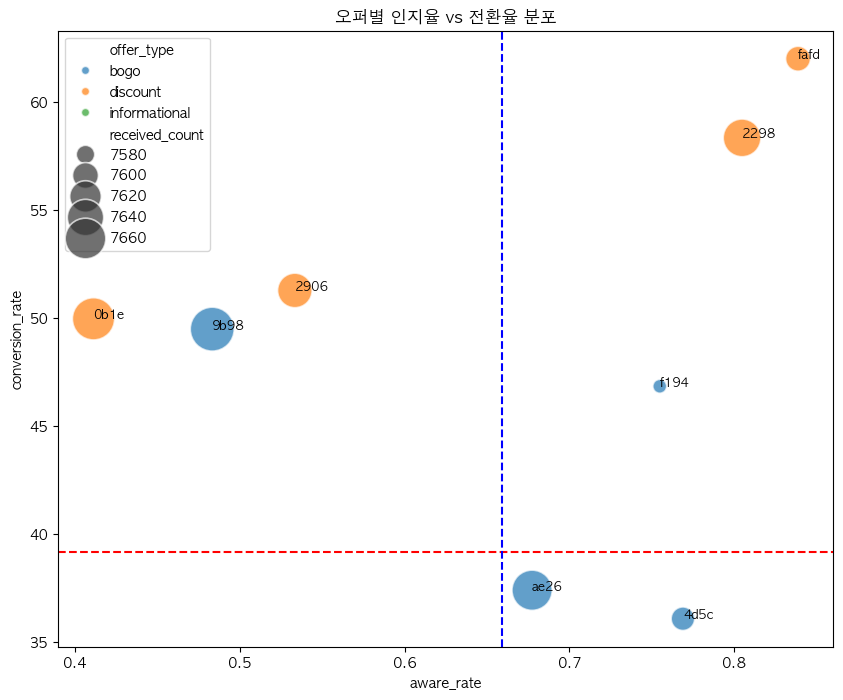

In [349]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=analysis_df, x='aware_rate', y='conversion_rate', 
                size='received_count', hue='offer_type', sizes=(100, 1000), alpha=0.7)

# 오퍼 id 점 옆에 표시
for i in range(analysis_df.shape[0]):
    plt.text(analysis_df.aware_rate[i], analysis_df.conversion_rate[i], 
             analysis_df.offer_id[i][:4], fontsize=9) # ID 앞 4자리만

plt.title('오퍼별 인지율 vs 전환율 분포')
plt.axhline(analysis_df['conversion_rate'].mean(), color='red', linestyle='--') # 평균선
plt.axvline(analysis_df['aware_rate'].mean(), color='blue', linestyle='--') # 평균선
plt.show()

### -> 우상단 : 효자상품 vs 좌상단 : 마케팅 전략을 더 잘 세워서 인지율을 높이도록!
#### 좌상단의 세 오퍼는 모두 ch_social==0인 오퍼!!

In [350]:
# '매력적인 오퍼'가 정말 '인지'와 '전환'도 잘 되고 있는지 상관관계 확인
correlation = analysis_df[['channel_count', 'duration', 'reward', 'difficulty', 'reward_ratio', 'offer_strength', 'aware_rate', 'conversion_rate']].corr()
display(correlation)

,channel_count,duration,reward,difficulty,reward_ratio,offer_strength,aware_rate,conversion_rate
channel_count,1.000000,-0.177287,0.110240,-0.313328,0.319470,0.424652,0.924360,0.267243
duration,-0.177287,1.000000,0.160262,0.808414,-0.012028,-0.791110,-0.284839,0.791976
reward,0.110240,0.160262,1.000000,0.465686,0.844821,0.165871,0.051683,0.313659
difficulty,-0.313328,0.808414,0.465686,1.000000,0.125191,-0.795447,-0.467730,0.640347
reward_ratio,0.319470,-0.012028,0.844821,0.125191,1.000000,0.439035,0.132171,0.355371
offer_strength,0.424652,-0.791110,0.165871,-0.795447,0.439035,1.000000,0.429735,-0.498776
aware_rate,0.924360,-0.284839,0.051683,-0.467730,0.132171,0.429735,1.000000,0.122404
conversion_rate,0.267243,0.791976,0.313659,0.640347,0.355371,-0.498776,0.122404,1.000000


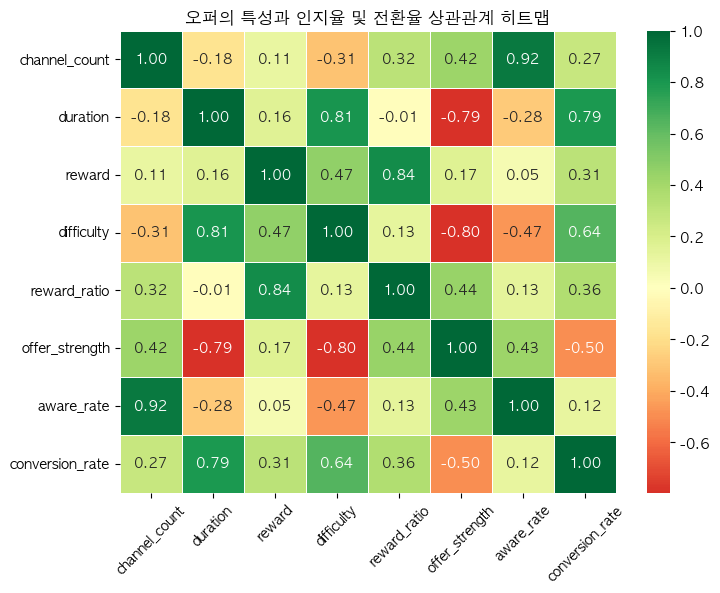

In [351]:
# 히트맵 (전체적인 상관관계 파악)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
plt.title('오퍼의 특성과 인지율 및 전환율 상관관계 히트맵')
plt.xticks(rotation=45)
plt.show()

In [352]:
discount_df = analysis_df[analysis_df['offer_type']=='discount']
bogo_df = analysis_df[analysis_df['offer_type']=='bogo']

discount_corr = discount_df[['channel_count', 'duration', 'reward', 'difficulty', 'reward_ratio', 'offer_strength', 'aware_rate', 'conversion_rate']].corr()
print("discount 오퍼의 특성과 인지율 및 전환율의 상관관계:\n", discount_corr)

bogo_corr = bogo_df[['channel_count', 'duration', 'reward', 'difficulty', 'reward_ratio', 'offer_strength', 'aware_rate', 'conversion_rate']].corr()
print("bogo 오퍼의 특성과 인지율 및 전환율의 상관관계:\n", bogo_corr)

discount 오퍼의 특성과 인지율 및 전환율의 상관관계:
                  channel_count  duration    reward  difficulty  reward_ratio  \
channel_count         1.000000 -0.301511 -0.738549   -0.904274      0.349394   
duration             -0.301511  1.000000  0.408248    0.660827     -0.474921   
reward               -0.738549  0.408248  1.000000    0.830097      0.217152   
difficulty           -0.904274  0.660827  0.830097    1.000000     -0.364056   
reward_ratio          0.349394 -0.474921  0.217152   -0.364056      1.000000   
offer_strength        0.894468 -0.694314 -0.721515   -0.985022      0.519198   
aware_rate            0.978260 -0.122263 -0.622040   -0.797886      0.357758   
conversion_rate       0.909039  0.118176 -0.548522   -0.646004      0.214677   

                 offer_strength  aware_rate  conversion_rate  
channel_count          0.894468    0.978260         0.909039  
duration              -0.694314   -0.122263         0.118176  
reward                -0.721515   -0.622040        -0.5

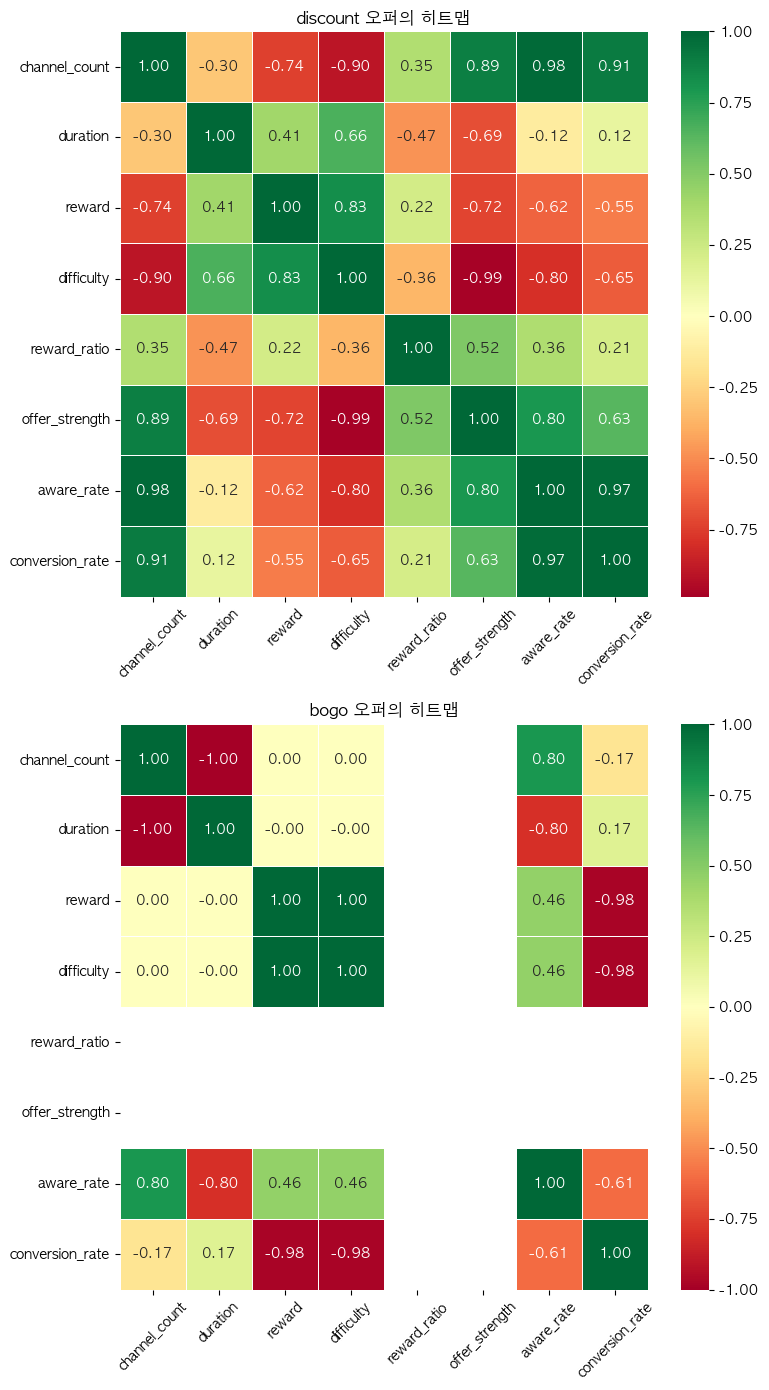

In [353]:
fig, axes = plt.subplots(2, 1, figsize=(8, 14))

ax1 = axes[0]
ax2 = axes[1]
label = ['discount', 'bogo']

sns.heatmap(discount_corr, ax=ax1, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
sns.heatmap(bogo_corr, ax=ax2, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)

for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=45)

ax1.set_title(f"{label[0]} 오퍼의 히트맵")
ax2.set_title(f"{label[1]} 오퍼의 히트맵")

plt.tight_layout()
plt.show()

### aware_rate와 channel_count는 강한 양의 상관관계
### aware_rate와 difficulty는 상관 없음 (오퍼의 종류에 따라 차이가 큼)

### conversion_rate와 duration은 강한 양의 상관관계를 보이는 듯 하지만 결국 duration에 의한 차이가 아닌, 오퍼 종류(bogo vs discount)에 따른 차이였음

<Figure size 1000x600 with 0 Axes>

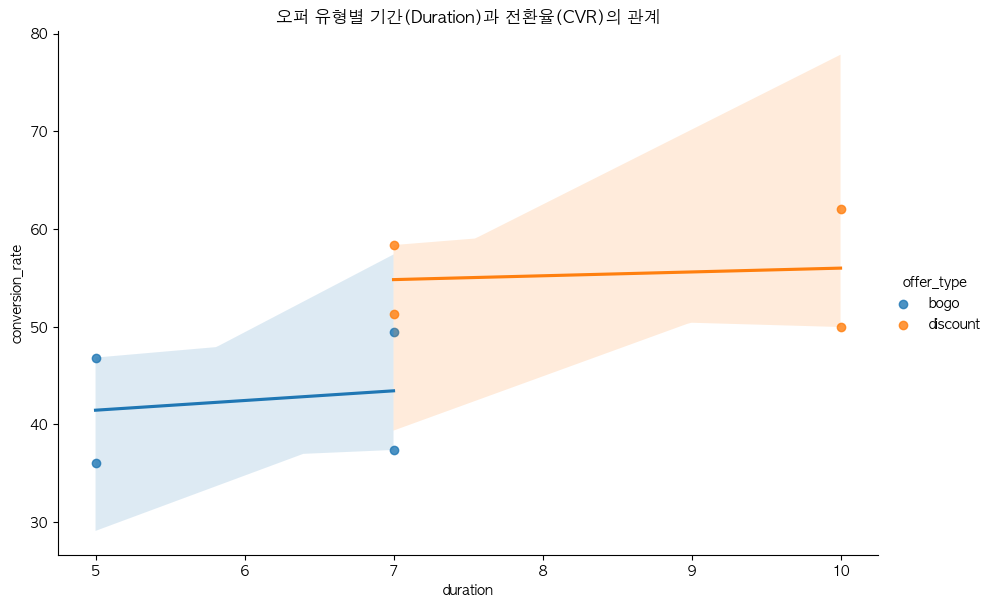

In [354]:
# 1. Informational 제외 (CVR이 있는 것만)
plot_df = analysis_df.dropna(subset=['conversion_rate'])
plot_df = plot_df[plot_df['offer_type'] != 'informational']

# 2. 전체 회귀선과 그룹별 분포를 동시에 확인
plt.figure(figsize=(10, 6))
sns.lmplot(data=plot_df, x='duration', y='conversion_rate', hue='offer_type', height=6, aspect=1.5)
plt.title('오퍼 유형별 기간(Duration)과 전환율(CVR)의 관계')
plt.show()

In [355]:
# ### merged_df
# customer_id	offer_id	time_comp	time_view	is_aware
# 19009	0009655768c64bdeb2e877511632db8f	f19421c1d4aa40978ebb69ca19b0e20d	414	456.0	False
# 29211	0009655768c64bdeb2e877511632db8f	fafdcd668e3743c1bb461111dcafc2a4	528	540.0	False
# 33136	0009655768c64bdeb2e877511632db8f	2906b810c7d4411798c6938adc9daaa5	576	NaN	False
# 11281	0011e0d4e6b944f998e987f904e8c1e5	2298d6c36e964ae4a3e7e9706d1fb8c2	252	186.0	True
# 33157	0011e0d4e6b944f998e987f904e8c1e5	9b98b8c7a33c4b65b9aebfe6a799e6d9	576	516.0	True
# ...	...	...	...	...	...
# 8406	ffff82501cea40309d5fdd7edcca4a07	0b1e1539f2cc45b7b9fa7c272da2e1d7	198	174.0	True
# 16771	ffff82501cea40309d5fdd7edcca4a07	2906b810c7d4411798c6938adc9daaa5	384	354.0	True
# 18926	ffff82501cea40309d5fdd7edcca4a07	2906b810c7d4411798c6938adc9daaa5	414	354.0	True
# 26299	ffff82501cea40309d5fdd7edcca4a07	9b98b8c7a33c4b65b9aebfe6a799e6d9	504	534.0	False
# 33028	ffff82501cea40309d5fdd7edcca4a07	2906b810c7d4411798c6938adc9daaa5	576	414.0	True

In [356]:
# is_aware == True인 그룹과 False인 그룹으로 나누어서 각 그룹의 채널 비교

# channel 테이블 준비 (복수 행 중복으로 처리)
channel = df[['customer_id', 'offer_id', 'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count']].drop_duplicates().copy() 

channel_df = merged_df.merge(channel, on=['customer_id', 'offer_id'], how='left')
display(channel_df) 

channel_comparison = channel_df.groupby('is_aware')[['ch_web', 'ch_email', 'ch_mobile', 'ch_social']].mean().T

print("그룹별 채널 노출 비중 비교:")
display(channel_comparison)

,customer_id,offer_id,time_comp,time_view,is_aware,ch_web,ch_email,ch_mobile,ch_social,channel_count
0,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,414,456.0,False,1.0,1.0,1.0,1.0,4.0
1,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,528,540.0,False,1.0,1.0,1.0,1.0,4.0
2,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,NaN,False,1.0,1.0,1.0,0.0,3.0
3,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,252,186.0,True,1.0,1.0,1.0,1.0,4.0
4,0011e0d4e6b944f998e987f904e8c1e5,9b98b8c7a33c4b65b9aebfe6a799e6d9,576,516.0,True,1.0,1.0,1.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...
33177,ffff82501cea40309d5fdd7edcca4a07,0b1e1539f2cc45b7b9fa7c272da2e1d7,198,174.0,True,1.0,1.0,0.0,0.0,2.0
33178,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,384,354.0,True,1.0,1.0,1.0,0.0,3.0
33179,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,414,354.0,True,1.0,1.0,1.0,0.0,3.0
33180,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,534.0,False,1.0,1.0,1.0,0.0,3.0


그룹별 채널 노출 비중 비교:


is_aware,False,True
ch_web,0.892078,0.889661
ch_email,1.000000,1.000000
ch_mobile,0.819027,0.938466
ch_social,0.444199,0.750549


- ch_web, ch_email은 True, False 그룹별 노출 비중의 차이가 거의 없음 --> 인지율에 결정적으로 영향을 미치는 요소는 아니다
- ch_mobile은 두 그룹별 노출 비중의 차이가 적음 --> 인지율에 약간의 영향을 미친다
- ch_social은 인지율을 높이는 핵심 채널이다 
### -> 고객들이 이벤트를 인지하게 만들고 싶다면 소셜 채널 (SNS) 광고 비중을 높여야한다!
#### 근데 혹시 소셜 채널 광고를 한 오퍼가 더 매력적이었던건 아닐까? reward가 높은 것 등등...

소셜 채널 포함 여부에 따른 오퍼 매력도 비교:


,channel_count,duration,reward,difficulty,reward_ratio,offer_strength,aware_rate,conversion_rate
ch_social,,,,,,,,
0.0,2.750000,7.000000,3.0,8.75,0.362500,-5.75,0.475843,37.678467
1.0,3.666667,6.166667,5.0,7.00,0.604762,-2.00,0.768898,40.104791


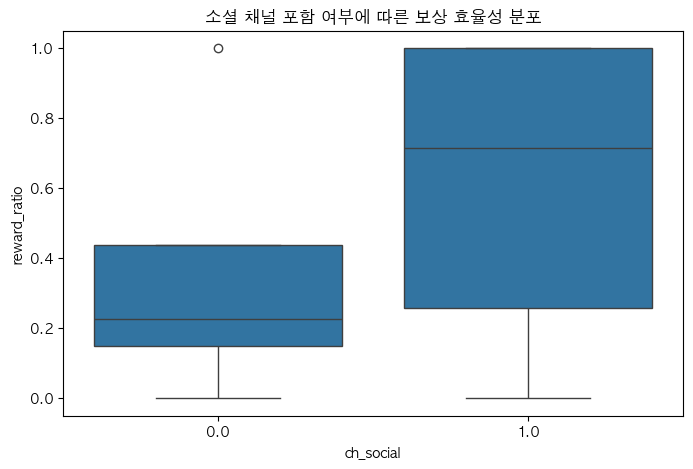

In [ ]:
# ch_social 유무에 따른 reward와 reward_ratio의 평균 비교
social_reward_check = analysis_df.groupby('ch_social')[['channel_count', 'duration', 'reward', 'difficulty', 'reward_ratio', 'offer_strength', 'aware_rate', 'conversion_rate']].mean()

print("소셜 채널 포함 여부에 따른 오퍼 매력도 비교:")
display(social_reward_check)

# 시각화
plt.figure(figsize=(8, 5))
sns.boxplot(data=analysis_df, x='ch_social', y='reward_ratio')
plt.title('소셜 채널 포함 여부에 따른 보상 효율성 분포')
plt.show()

### 소셜 광고를 했는데도 인지를 못한 그룹에 대한 인구통계학적 분석
#### ch_social==1 & is_aware==False

In [358]:
# # 1. 소셜 광고를 받았으나 인지하지 못한 그룹 필터링
# # 주의: 이 분석을 위해서는 merged_df에 고객 정보(age_group, income_group 등)가 결합되어 있어야 합니다.
# fail_social_group = channel_df[(channel_df['ch_social'] == 1) & (channel_df['is_aware'] == False)]

# # 2. 이 그룹의 나이와 소득 분포 확인
# age_dist = fail_social_group['age_group'].value_counts(normalize=True).sort_index()
# income_dist = fail_social_group['income_group'].value_counts(normalize=True).sort_index()

# print("소셜 광고 미인지 그룹의 연령대 비중:\n", age_dist)
# print("\n소셜 광고 미인지 그룹의 소득 수준 비중:\n", income_dist)

In [359]:
# 채널 활용 개수의 인지율 변화 확인
channel_size = channel_df.groupby('channel_count')['is_aware'].mean()
print(channel_size) 
"""channel_count
2.0    0.411078
3.0    0.559150
4.0    0.796265"""

channel_count
2.0    0.411078
3.0    0.559150
4.0    0.796265
Name: is_aware, dtype: float64


'channel_count\n2.0    0.411078\n3.0    0.559150\n4.0    0.796265'

### -> 이벤트 홍보 채널이 많아질 수록 인지율이 높아진다

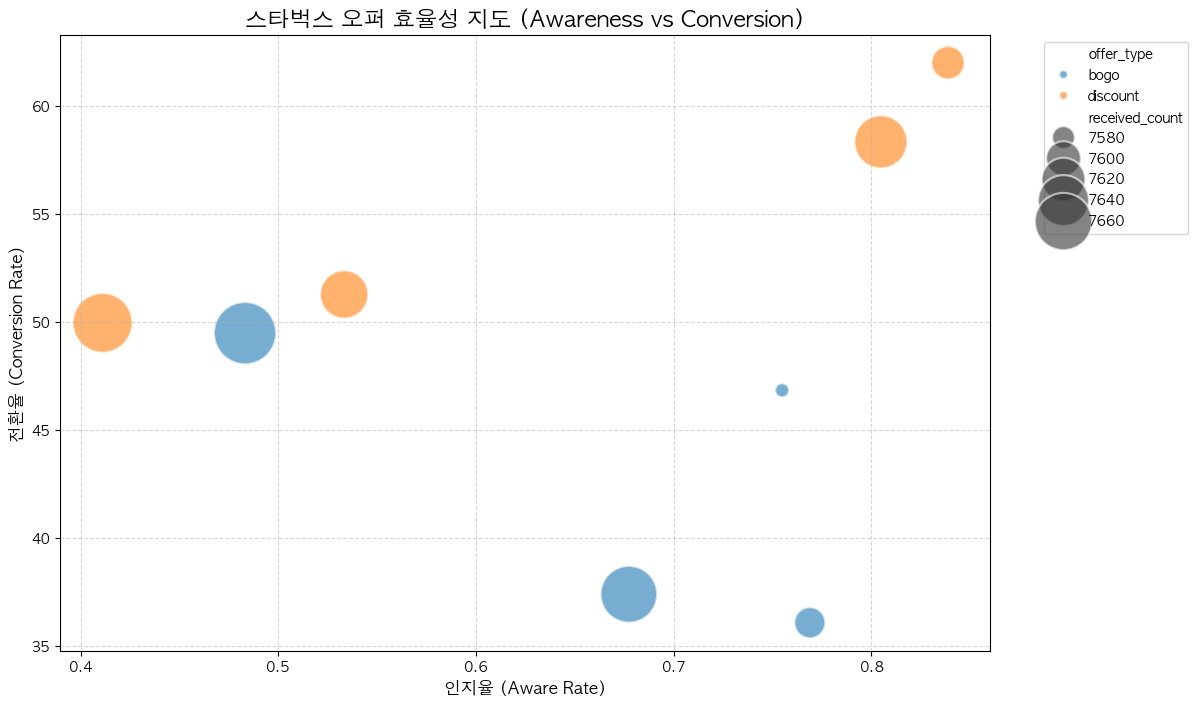

In [360]:
plt.figure(figsize=(12, 8))
# x축: 인지율, y축: 전환율, 점의 크기: 발송 횟수, 색상: 오퍼 타입
sns.scatterplot(data=analysis_df.dropna(), x='aware_rate', y='conversion_rate', 
                size='received_count', hue='offer_type', sizes=(100, 2000), alpha=0.6)

plt.title('스타벅스 오퍼 효율성 지도 (Awareness vs Conversion)', fontsize=16)
plt.xlabel('인지율 (Aware Rate)', fontsize=12)
plt.ylabel('전환율 (Conversion Rate)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()